In [1]:
import scanpy as sc
import squidpy as sq
import numpy as np
import matplotlib.pyplot as plt

from graph_transformer_long_range_niches.pp import sliding_window, split_adata
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
LEGNINI23 = "/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/legnini23.h5ad"

# Load data

In [3]:
adata = sc.read_h5ad(LEGNINI23)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [4]:
scales_counts

NameError: name 'scales_counts' is not defined

In [10]:
from scipy.sparse import csr_array, csr_matrix, issparse
# Normalization to the median
sc.pp.normalize_total(adata)

# Freeman-Tukey square root transform
assert issparse(adata.X)
sqrt_X = adata.X.sqrt()
# Create a new sparse matrix for X + 1
X_plus_1 = adata.X + csr_matrix(np.ones(adata.X.shape))
# Calculate the square root of (X + 1)
sqrt_X_plus_1 = X_plus_1.sqrt()
adata.layers['norm_ftsqrt'] = sqrt_X + sqrt_X_plus_1

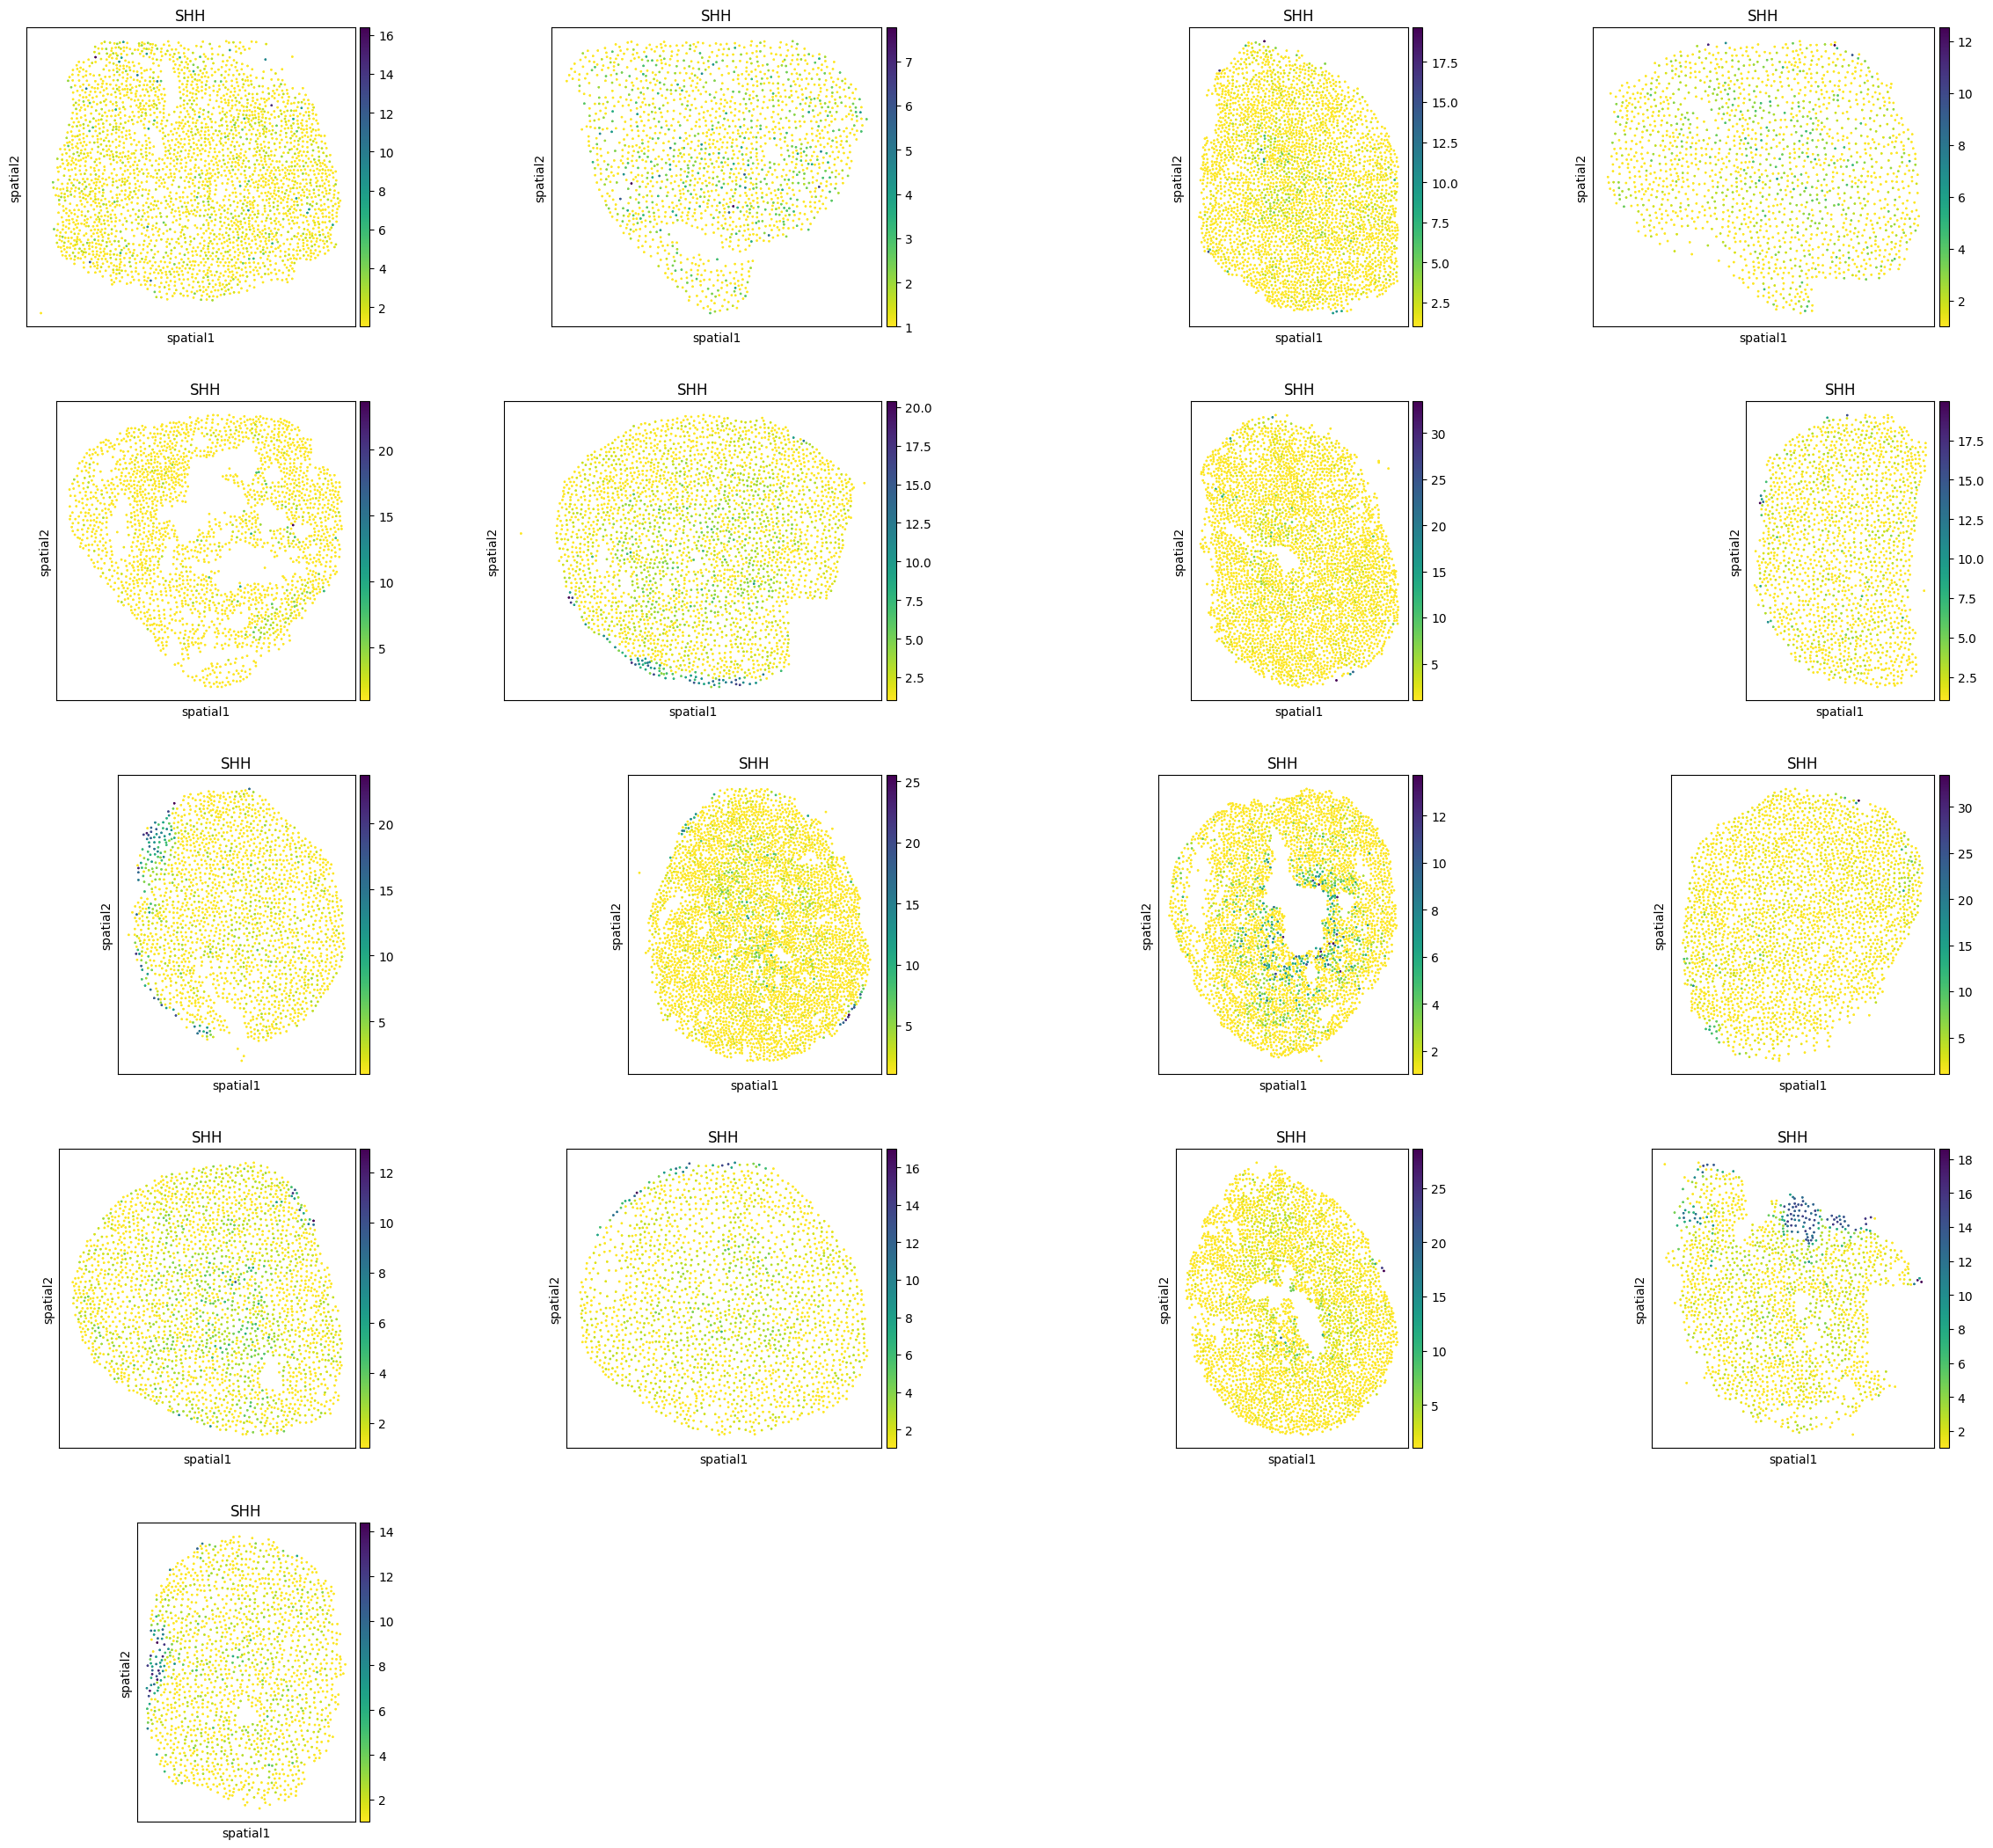

In [16]:
adata.X = adata.layers['norm_ftsqrt']
sq.pl.spatial_scatter(
        adata,
        library_key = 'sample',
        #library_id = shh_slides,
        color = ['SHH'],
        cmap = 'viridis_r',
        shape= None)

In [7]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["raw"] = adata.X
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [32]:
# adata.obsm['spatial'] = adata.obsm['coordinates']
# del adata.obsm['coordinates']

In [34]:
# np.isnan(adata.obsm["spatial"]).sum()

296

Remove all cells that have entry NaN in .obsm['coordinates'].
If NaN is in .obsm it leads to error when creating graph. Why is there NaN in obsm?
[NaN value when importing Visium datasete](https://github.com/scverse/squidpy/issues/797)

In [35]:
# Create a boolean mask for rows without NaN coordinates
valid_coords = ~np.isnan(adata.obsm["spatial"]).any(axis=1)

# Filter the AnnData object
adata = adata[valid_coords].copy()

# Verify the removal of NaN values
print(f"NaN values remaining: {np.isnan(adata.obsm['spatial']).sum()}")

NaN values remaining: 0


Make sure that obs_names are unique and convertable to string. 

In [49]:
adata.obs_names_make_unique

<bound method AnnData.obs_names_make_unique of AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'sliding_window_assignment', 'globalX', 'globalY'
    obsm: 'spatial'>

In [51]:
adata.obs['obs_names'] = adata.obs_names

In [59]:
adata.obs_names = np.array(range(adata.n_obs))

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/anndata/_core/anndata.py:841: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  names = self._prep_dim_index(names, "obs")


In [64]:
adata.obs_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '43752', '43753', '43754', '43755', '43756', '43757', '43758', '43759',
       '43760', '43761'],
      dtype='object', length=43762)

In [62]:
adata.write(LEGNINI23)

In [44]:
adata.obs_names = adata.obs_names.str.replace('-', '', regex=False)

In [39]:
adata.obs_names

Index(['A2-1_c1', 'A2-1_c10', 'A2-1_c100', 'A2-1_c1000', 'A2-1_c1001',
       'A2-1_c1002', 'A2-1_c1003', 'A2-1_c1004', 'A2-1_c1005', 'A2-1_c1006',
       ...
       'W5A3_c990', 'W5A3_c991', 'W5A3_c992', 'W5A3_c993', 'W5A3_c994',
       'W5A3_c995', 'W5A3_c996', 'W5A3_c997', 'W5A3_c998', 'W5A3_c999'],
      dtype='object', length=43762)

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' wi

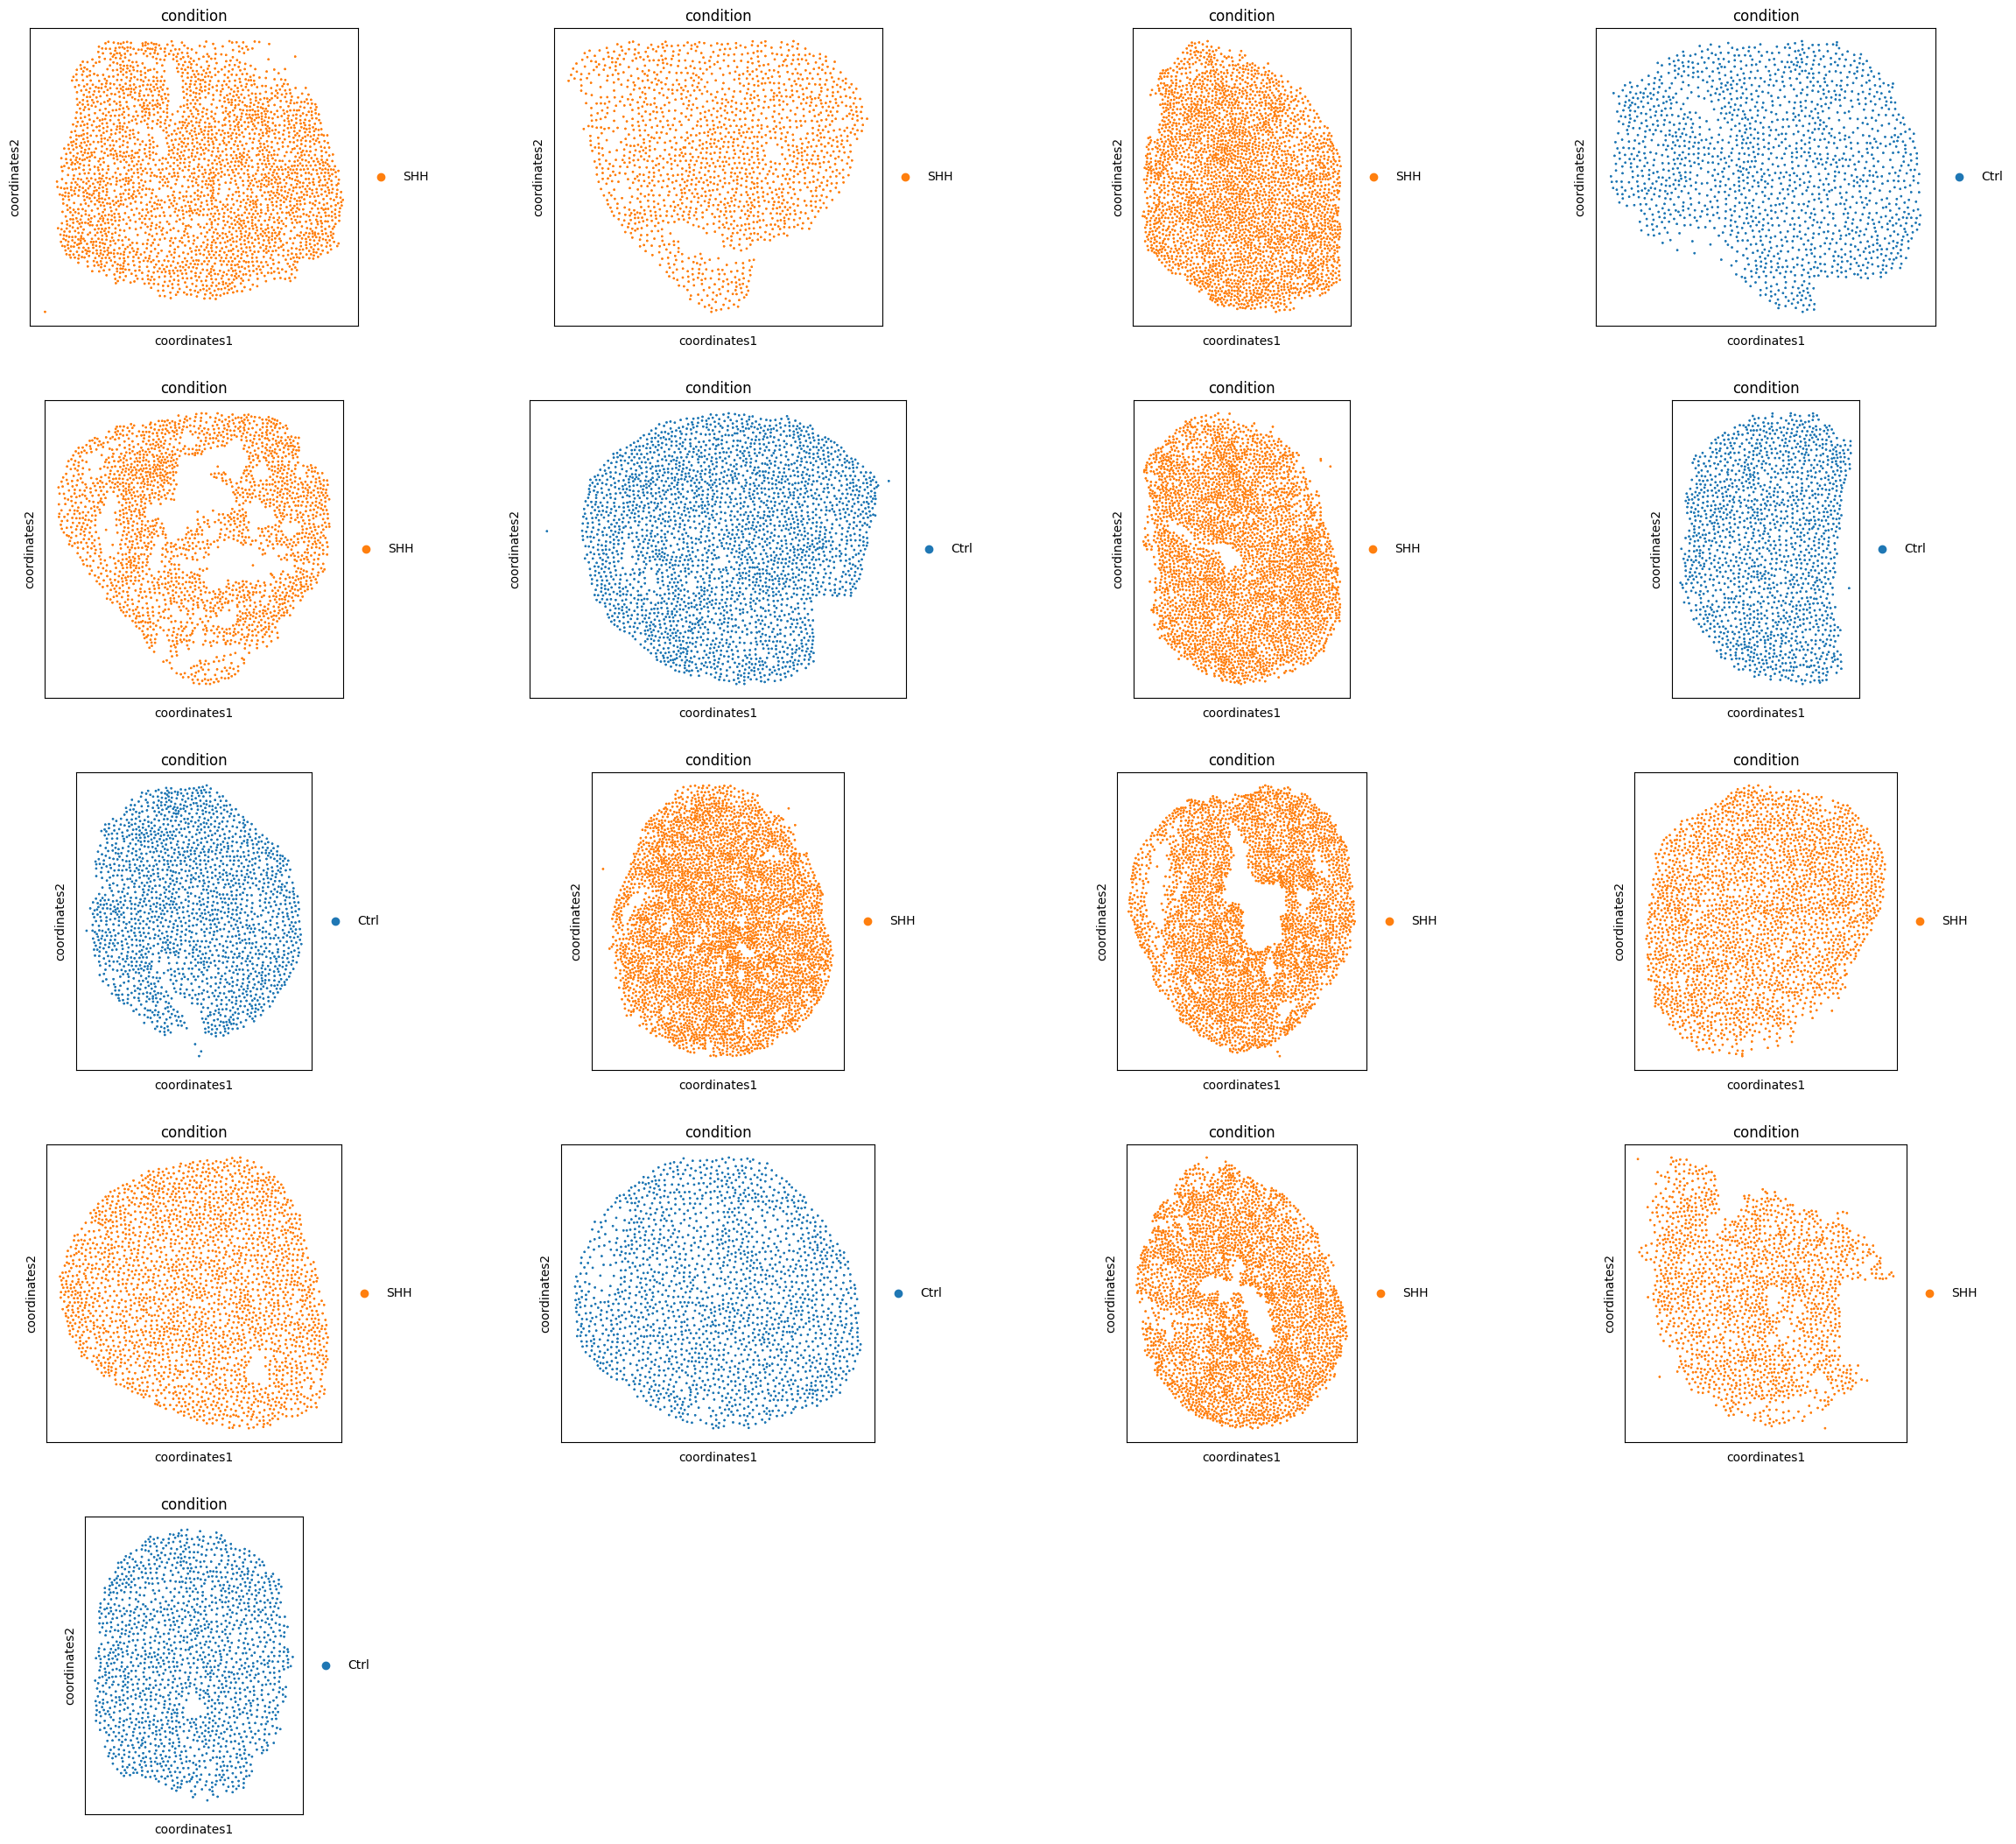

In [6]:
sq.pl.spatial_scatter(
        adata,
        library_key = 'sample',
        color = ['condition'],
        spatial_key = 'coordinates',
        shape= None,
)

In [16]:
adata.obs.groupby('sample').size()

/tmp/ipykernel_3699575/3476541920.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('sample').size()


sample
slide1_A2-1    3091
slide1_A2-2    1774
slide1_B2-1    3299
slide1_B2-2    1701
slide1_B2-3    2241
slide1_C2-1    2870
slide1_C2-2    3510
slide1_C2-3    1640
slide1_C2-5    1958
slide1_D2-2    4318
slide1_D2-3    3621
slide4_A2-1    2630
slide4_A2-2    2506
slide4_A2-3    1984
slide4_B2-1    3345
slide4_B2-2    1779
slide4_B2-3    1643
dtype: int64

In [24]:
adata

AnnData object with n_obs × n_vars = 43910 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid'
    obsm: 'coordinates'

In [23]:
sliding_window(adata, library_key = 'sample', window_size=2100, overlap=0, spatial_key='coordinates')

AttributeError: 'float' object has no attribute 'split'

In [18]:
adata

AnnData object with n_obs × n_vars = 43910 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'split'
    obsm: 'coordinates'

In [4]:
split_adata(adata, split_obs='sample', val_size=0.2, test_size=0.1, seed = 44, stratify_groups='condition')
adata.obs.groupby(['split', 'condition']).size()

Stratifying by conditions: ['Ctrl' 'SHH']
Test size > 0
{'counts': {'train': 29347, 'val': 10800, 'test': 3763}, 'groups': {'train': ['slide1_A2-2', 'slide4_B2-3', 'slide1_C2-1', 'slide1_D2-3', 'slide4_B2-1', 'slide1_B2-2', 'slide4_A2-1', 'slide1_C2-3', 'slide1_B2-1', 'slide1_D2-2', 'slide4_A2-2'], 'val': ['slide1_C2-2', 'slide1_B2-3', 'slide1_C2-5', 'slide1_A2-1'], 'test': ['slide4_A2-3', 'slide4_B2-2']}}


/tmp/ipykernel_620621/1074495805.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(['split', 'condition']).size()


split  condition
test   Ctrl          1984
       SHH           1779
train  Ctrl          7854
       SHH          21493
val    Ctrl          1958
       SHH           8842
dtype: int64

In [20]:
sq.gr.spatial_neighbors(adata, 
                        library_key = 'sample', 
                        spatial_key = 'coordinates')

ValueError: Input X contains NaN.
NearestNeighbors does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [23]:
adata.var_names_make_unique()

In [28]:
sq.gr.spatial_neighbors(adata, spatial_key='coordinates')